# NDVI Smoothing Comparison

## Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

!pip install pybaselines
from pybaselines.whittaker import asls

from sklearn.metrics import mean_squared_error

## Load Dataset

In [61]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine Work

In [62]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Remove missing value
df.dropna(inplace=True)

# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

## Report from Day-1

### Summary of the Dataset

The exploratory analysis of the raw Sentinel-2 NDVI time series produced the following key findings:

- **Total observations:** **69** valid NDVI observations were available for analysis.
- **Temporal coverage:** The dataset spans from **2023-01-09** to **2025-12-19**.
- **Data quality:** 3 duplicate observation dates remained after preprocessing, and missing NDVI values were removed prior to analysis.
- **NDVI statistics:**
  - Mean NDVI: **0.517823**
  - Median NDVI: **0.510964**
  - Minimum NDVI: **0.196364**
  - Maximum NDVI: **0.830655**
  - Standard deviation: **0.167828**

### Temporal Observation Characteristics

- The **mean revisit interval** was approximately **15.808824 days**, while the **median revisit interval** was **5.000000 days**.
- The **longest observation gap** was **160 days**.
- A total of **8** observation gaps exceeded **20 days**, indicating periods of reduced satellite availability, most likely caused by cloud cover, rainfall, or cloud masking during image preprocessing.
- The observation timeline revealed that satellite acquisitions were **temporally irregular**, with both densely sampled and sparsely sampled periods.

### NDVI Distribution

- NDVI values ranged from **0.83** to **0.19**.
- The boxplot indicated **no obvious outliers**, suggesting that the raw observations generally fall within an expected range for agricultural vegetation.



## Smoothing

Raw Sentinel-2 NDVI time series often contain fluctuations caused by sensor noise, cloud contamination, atmospheric effects, mixed pixels, and irregular observation intervals. These factors introduce measurement uncertainty and can obscure the true vegetation signal.

Smoothing reduces short-term noise while preserving the overall seasonal trend, making the time series more suitable for interpolation, phenology analysis, and feature extraction.

## Create a Copy of the Data

In [63]:
smooth_df = df.copy()

## Moving Average Smoothing

In [64]:
# Window sizes
ma_windows = [3, 5, 7]

for window in ma_windows:
    smooth_df[f"MA_{window}"] = (
        smooth_df["NDVI"]
        .rolling(window=window, center=True)
        .mean()
    )

display(smooth_df.head())

,NDVI,MA_3,MA_5,MA_7
date,,,,
2023-01-09,0.533609,NaN,NaN,NaN
2023-01-19,0.379122,0.494266,NaN,NaN
2023-01-24,0.570066,0.495117,0.500058,NaN
2023-02-03,0.536162,0.529186,0.473177,0.455107
2023-02-13,0.481330,0.472232,0.454603,0.408535


### Plot Moving Average

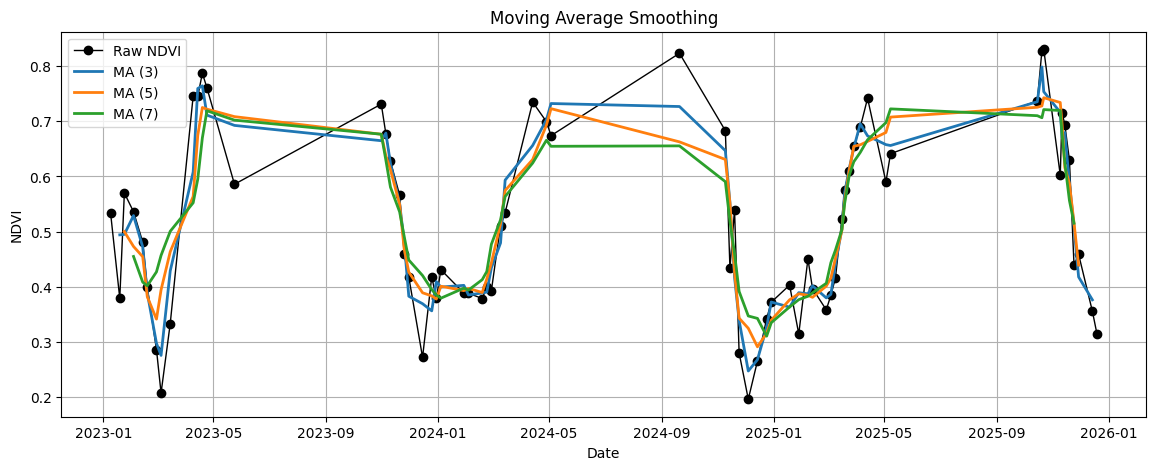

In [65]:
plt.figure(figsize=(14,5))

plt.plot(
    smooth_df.index,
    smooth_df["NDVI"],
    color="black",
    linewidth=1,
    marker="o",
    label="Raw NDVI"
)

for window in ma_windows:
    plt.plot(
        smooth_df.index,
        smooth_df[f"MA_{window}"],
        linewidth=2,
        label=f"MA ({window})"
    )

plt.title("Moving Average Smoothing")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Savitzky–Golay Filter

In [66]:
window_length = 7
poly_order = 2

smooth_df["Savitzky_Golay"] = savgol_filter(
    smooth_df["NDVI"],
    window_length=window_length,
    polyorder=poly_order
)

### Plot Savitzky–Golay

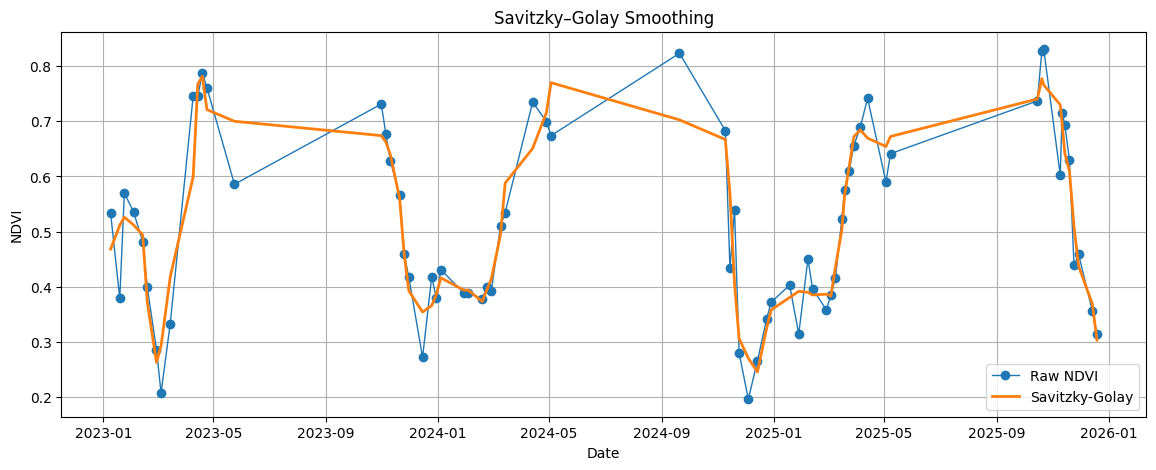

In [67]:
plt.figure(figsize=(14,5))

plt.plot(
    smooth_df.index,
    smooth_df["NDVI"],
    marker="o",
    linewidth=1,
    label="Raw NDVI"
)

plt.plot(
    smooth_df.index,
    smooth_df["Savitzky_Golay"],
    linewidth=2,
    label="Savitzky-Golay"
)

plt.title("Savitzky–Golay Smoothing")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Whittaker Smoothing

In [68]:
lambda_value = 0.05

baseline, params = asls(
    smooth_df["NDVI"],
    lam=lambda_value
)

smooth_df["Whittaker"] = baseline

## Plot Whittaker

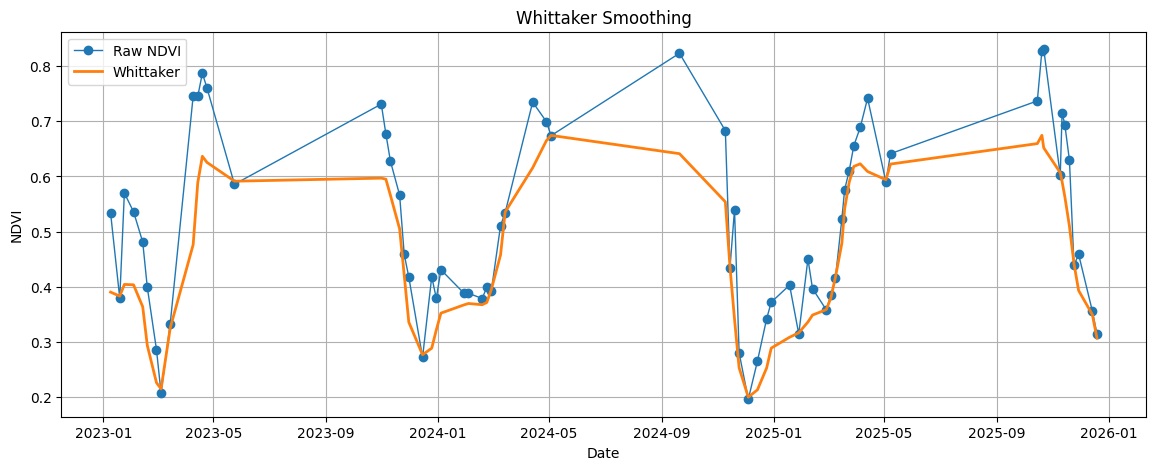

In [69]:
plt.figure(figsize=(14,5))

plt.plot(
    smooth_df.index,
    smooth_df["NDVI"],
    marker="o",
    linewidth=1,
    label="Raw NDVI"
)

plt.plot(
    smooth_df.index,
    smooth_df["Whittaker"],
    linewidth=2,
    label="Whittaker"
)

plt.title("Whittaker Smoothing")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

## Asymmetric Whittaker

In [70]:
lam = 1
p = 0.5

aws, params = asls(
    smooth_df["NDVI"].values,
    lam=lam,
    p=p
)

smooth_df["AWS"] = aws

### Ploting Asymmetric Whittaker

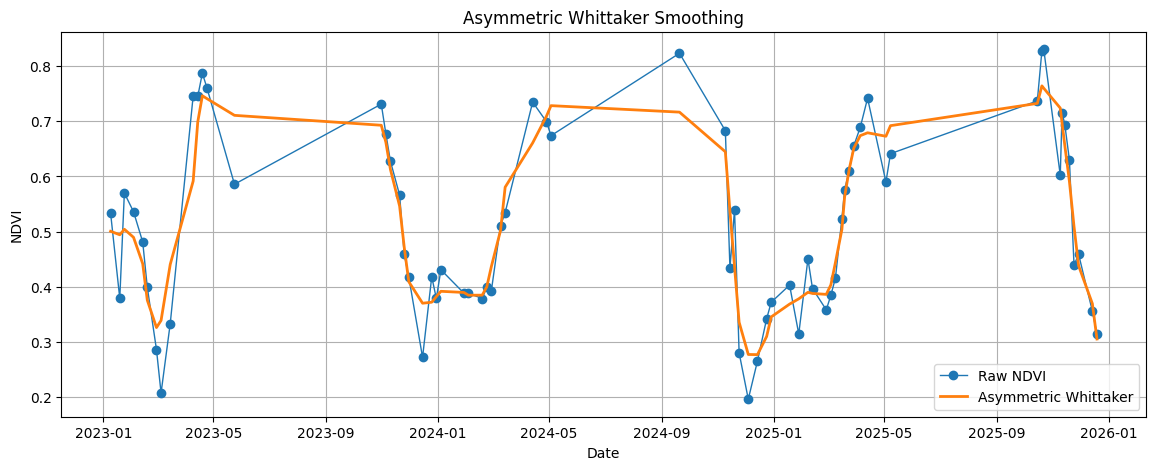

In [71]:
plt.figure(figsize=(14,5))

plt.plot(
    smooth_df.index,
    smooth_df["NDVI"],
    marker="o",
    linewidth=1,
    label="Raw NDVI"
)

plt.plot(
    smooth_df.index,
    smooth_df["AWS"],
    linewidth=2,
    label="Asymmetric Whittaker"
)

plt.title("Asymmetric Whittaker Smoothing")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

In [72]:
display(
    smooth_df[
        [
            "NDVI",
            "MA_3",
            "MA_5",
            "MA_7",
            "Savitzky_Golay",
            "AWS",
            "Whittaker"
        ]
    ].head(10)
)

,NDVI,MA_3,MA_5,MA_7,Savitzky_Golay,AWS,Whittaker
date,,,,,,,
2023-01-09,0.533609,NaN,NaN,NaN,0.468418,0.500739,0.390489
2023-01-19,0.379122,0.494266,NaN,NaN,0.511581,0.494357,0.383119
2023-01-24,0.570066,0.495117,0.500058,NaN,0.526184,0.504411,0.404373
2023-02-03,0.536162,0.529186,0.473177,0.455107,0.512227,0.489718,0.403749
2023-02-13,0.481330,0.472232,0.454603,0.408535,0.494143,0.441925,0.363881
2023-02-18,0.399204,0.388929,0.382111,0.402014,0.372578,0.375897,0.293887
2023-02-28,0.286252,0.297687,0.341574,0.427156,0.263076,0.326207,0.226376
2023-03-05,0.207605,0.275778,0.394520,0.457012,0.293068,0.339076,0.215018
2023-03-15,0.333477,0.429047,0.463710,0.500708,0.417987,0.440752,0.325460


## Preliminary Observations

Several smoothing methods were applied to the raw Sentinel-2 NDVI time series.

Initial visual inspection suggests that:

- The Moving Average filter reduces short-term fluctuations but increasingly suppresses peaks as the window size increases.
- The Savitzky–Golay filter preserves local maxima and minima while reducing noise.
- The Whittaker smoother generates a globally smooth signal while maintaining the overall seasonal vegetation trend.

A quantitative comparison of these methods will be performed in the next section using peak characteristics, smoothness metrics, and Root Mean Square Error (RMSE).

## Quantitative Comparison of Smoothing Methods

### Combined Comparison Plot

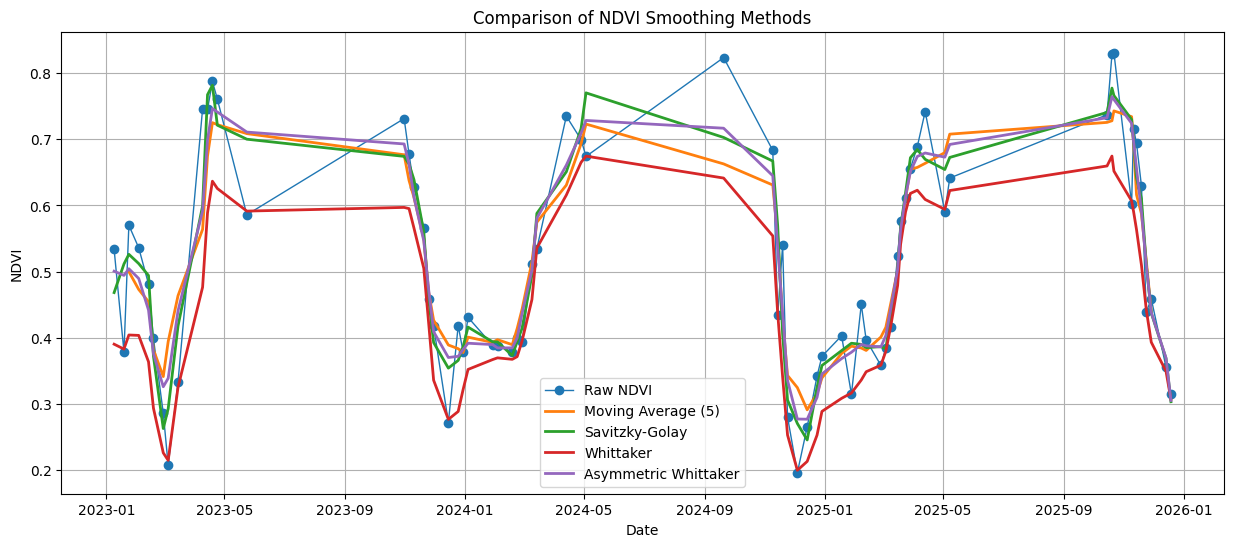

In [73]:
plt.figure(figsize=(15, 6))

plt.plot(
    smooth_df.index,
    smooth_df["NDVI"],
    "o-",
    linewidth=1,
    label="Raw NDVI"
)

plt.plot(
    smooth_df.index,
    smooth_df["MA_5"],
    linewidth=2,
    label="Moving Average (5)"
)

plt.plot(
    smooth_df.index,
    smooth_df["Savitzky_Golay"],
    linewidth=2,
    label="Savitzky-Golay"
)


plt.plot(
    smooth_df.index,
    smooth_df["Whittaker"],
    linewidth=2,
    label="Whittaker"
)

plt.plot(
    smooth_df.index,
    smooth_df["AWS"],
    linewidth=2,
    label="Asymmetric Whittaker"
)

plt.title("Comparison of NDVI Smoothing Methods")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)
plt.legend()

plt.show()

### Peak NDVI Comparison

In [74]:
methods = [
    "NDVI",
    "MA_5",
    "Savitzky_Golay",
    "AWS",
    "Whittaker"
]

peak_values = {}

for method in methods:
    peak_values[method] = smooth_df[method].max()

peak_table = pd.DataFrame.from_dict(
    peak_values,
    orient="index",
    columns=["Peak NDVI"]
)

peak_table

,Peak NDVI
NDVI,0.830655
MA_5,0.742775
Savitzky_Golay,0.781529
AWS,0.764254
Whittaker,0.674553


### RMSE Calculation

In [79]:
rmse = {}

for method in methods[1:]:

    temp = smooth_df[["NDVI", method]].dropna()

    rmse[method] = np.sqrt(
        mean_squared_error(
            temp["NDVI"],
            temp[method]
        )
    )

rmse_table = pd.DataFrame.from_dict(
    rmse,
    orient="index",
    columns=["RMSE"]
)

display(rmse_table)

,RMSE
MA_5,0.070736
Savitzky_Golay,0.056951
AWS,0.057611
Whittaker,0.092522


## Interpretation of Quantitative Metrics

Each evaluation metric measures a different aspect of smoothing performance.

- **Peak NDVI:** Indicates how well the method preserves the maximum vegetation signal.
- **RMSE:** Measures the average deviation between the raw observations and the smoothed signal.

These metrics should be interpreted together rather than individually. A method with the lowest RMSE is not necessarily the best if it excessively smooths the vegetation signal or shifts important phenological events.